# 03 — Modelagem: regressão multivariada (painel pooled)

**Pré-requisito:** `02_transformacao.ipynb` já executado (`data/processed/feature_matrix.parquet` disponível — painel município × ano para **2022, 2023, 2024**).

**Hipótese de trabalho:** a taxa de mortalidade por causas evitáveis (sensíveis ao SUS e ao desenvolvimento socioeconômico) de cada município brasileiro é função de variáveis socioeconômicas (IDH-M, Gini, renda, escolaridade, saneamento) e do esforço de saúde pública (despesa em saúde per capita), controlando pelo porte populacional, região e ano.

## Por que pooled, e não modelo de painel completo?

Com 3 anos, temos duas opções: (a) **pooled OLS** com `ANO` como dummy de tempo (controla choques anuais comuns como pós-COVID, mudanças no SUS); (b) **fixed effects de município**, que controlaria todas as características invariantes do município. A opção (b) **não é identificável** aqui porque a maior parte das nossas features (IDH-M, Gini, RDPC, T_AGUA, ESPVIDA, T_ANALF15M) vem do Atlas DH 2010 e é **constante ao longo dos anos**. Fixed effects de município absorveria todo o efeito dessas variáveis. Resta o pooled com:

- **ANO dummies** — captura tendência de período (efeitos comuns em cada ano).
- **Standard errors cluster-robust por município** — corrige a correlação intra-município entre observações 2022/2023/2024 (mesma cidade, choque persistente).
- **Train/test split por município** — `GroupShuffleSplit` impede que o mesmo município apareça em treino e teste com anos diferentes (evita data leakage no R² de teste).

## Etapas

1. **Carregamento** — `feature_matrix.parquet` (~16.7k obs = 5.570 mun × 3 anos).
2. **EDA do target** — distribuição, variação entre anos.
3. **Matriz de correlação** — relação linear entre features e target.
4. **Modelo Linear (OLS)** — interpretabilidade: coeficientes e p-values cluster-robust via `statsmodels`.
5. **Modelos não-lineares** — Random Forest e XGBoost para capturar efeitos não-lineares e interações.
6. **Comparação** — R², RMSE, MAE em hold-out de teste (split por município).
7. **Importância das features** — qual variável mais explica a taxa de mortalidade evitável.
8. **Análise contrafactual** — se elevarmos o IDH-M dos municípios mais pobres, o que acontece com a previsão?
9. **Persistência** — `models/` com previsões e métricas.

## Saída

```
data/processed/
└── predicoes_modelo.parquet      # município × ano → taxa real, predita, resíduo

models/
├── metricas_modelos.csv          # R², RMSE, MAE por modelo
├── coeficientes_ols.csv          # coef + std error cluster-robust + p-value
└── importancia_features.csv      # ranking RF + XGB
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

ROOT          = Path.cwd().parent
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR    = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
print("Imports OK")

Imports OK


## 1. Carregamento e preparação

Carrega a feature matrix gerada no notebook 02, descarta registros sem cobertura completa nas features socioeconômicas e define o target.

In [2]:
fm = pd.read_parquet(PROCESSED_DIR / "feature_matrix.parquet")
fm["CODMUN6"] = fm["CODMUN6"].astype(str).str.zfill(6)
fm["ANO"]     = fm["ANO"].astype(int)
print(f"Feature matrix bruta: {fm.shape[0]:,} linhas × {fm.shape[1]} colunas")
print(f"Anos cobertos      : {sorted(fm['ANO'].unique())}")
fm.head()

Feature matrix bruta: 16,711 linhas × 34 colunas
Anos cobertos      : [np.int64(2022), np.int64(2023), np.int64(2024)]


,CODMUN6,MUNICIPIO_NOME,ANO,POPULACAO,OBITOS_EVITAVEIS,PIB_RS_MIL,DESPESA_SAUDE_RS,CODMUN7,IDHM,IDHM_E,IDHM_L,IDHM_R,GINI,RDPC,RDPC1,RDPC2,RDPC3,RDPC4,RDPC5,PMPOB,PIND,THEIL,ESPVIDA,T_ANALF15M,T_AGUA,UF,REGIAO,PIB_PER_CAPITA,DESPESA_SAUDE_PC,TAXA_EVITAVEL_100K,LOG_PIB_PER_CAPITA,LOG_DESPESA_SAUDE_PC,LOG_POPULACAO,TAXA_PADRONIZADA_100K
0,110001,Alta Floresta D'Oeste - RO,2022,21494.0,55,919520.0,2.918174e+07,1100015,0.641,0.526,0.763,0.657,0.58,476.99,36.89,160.31,289.97,469.88,1424.61,26.04,14.29,0.60,70.75,11.99,93.69,RO,N,42780.310784,1357.669117,255.885363,10.663857,7.214261,9.975576,300.040437
1,110002,Ariquemes - RO,2022,96833.0,209,3809355.0,1.193331e+08,1100023,0.702,0.600,0.806,0.716,0.53,689.95,120.08,270.77,420.44,638.10,1996.77,11.54,4.36,0.51,73.36,7.90,98.54,RO,N,39339.429740,1232.359333,215.835511,10.580008,7.117497,11.480753,288.266595
2,110003,Cabixi - RO,2022,5351.0,8,289783.0,1.093209e+07,1100031,0.650,0.559,0.757,0.650,0.51,457.17,78.16,181.72,292.34,480.37,1256.80,21.20,7.27,0.44,70.39,13.63,95.49,RO,N,54154.924313,2042.999993,149.504765,10.899623,7.622664,8.585226,154.284260
3,110004,Cacoal - RO,2022,86887.0,181,3195489.0,7.671583e+07,1100049,0.718,0.620,0.821,0.727,0.57,738.06,108.24,265.14,431.80,656.39,2247.76,13.08,5.97,0.61,74.27,8.29,97.96,RO,N,36777.527133,882.937968,208.316549,10.512669,6.784387,11.372375,259.868382
4,110005,Cerejeiras - RO,2022,15890.0,29,903099.0,2.560032e+07,1100056,0.692,0.602,0.799,0.688,0.50,577.18,104.82,236.32,389.57,581.95,1568.87,13.70,4.72,0.46,72.94,10.29,97.53,RO,N,56834.424166,1611.096328,182.504720,10.947915,7.385291,9.673508,212.808059


In [3]:
# Alvo: taxa PADRONIZADA por idade (notebook 06). Corrige o paradoxo da taxa bruta
# (Sul/Sudeste apareciam no topo só por terem população mais velha).
TARGET = "TAXA_PADRONIZADA_100K"

FEATURES_NUM = [
    "LOG_PIB_PER_CAPITA",     # escala econômica (log para reduzir cauda)
    "LOG_DESPESA_SAUDE_PC",   # esforço de saúde pública per capita (varia por ano)
    "LOG_POPULACAO",          # controle de porte (taxa em pequenos municípios é volátil)
    "IDHM",                    # desenvolvimento humano (Atlas 2010, time-invariant)
    "GINI",                    # desigualdade de renda (Atlas 2010, time-invariant)
    "RDPC",                    # renda domiciliar per capita (Atlas 2010, time-invariant)
    "PMPOB",                   # % de pobres (Atlas 2010, time-invariant)
    "ESPVIDA",                 # esperança de vida ao nascer (Atlas 2010, time-invariant)
    "T_ANALF15M",              # taxa de analfabetismo 15+ (Atlas 2010, time-invariant)
    "T_AGUA",                  # % com acesso a água encanada (Atlas 2010, time-invariant)
]
FEATURES_CAT = ["REGIAO", "ANO"]   # ANO entra como dummy para year fixed effects

cols_necessarias = [TARGET] + FEATURES_NUM + FEATURES_CAT
df_model = fm[["CODMUN6", "MUNICIPIO_NOME", "UF"] + cols_necessarias].dropna().copy()

# One-hot encoding de REGIAO e ANO (drop_first p/ evitar colinearidade)
df_model = pd.get_dummies(df_model, columns=FEATURES_CAT, prefix=["REG", "ANO"], drop_first=True, dtype=float)
REGIAO_DUMMIES = [c for c in df_model.columns if c.startswith("REG_")]
ANO_DUMMIES    = [c for c in df_model.columns if c.startswith("ANO_")]
FEATURES = FEATURES_NUM + REGIAO_DUMMIES + ANO_DUMMIES

print(f"Alvo              : {TARGET} (padronizada por idade)")
print(f"Após dropna       : {df_model.shape[0]:,} obs (município × ano)")
print(f"Municípios únicos : {df_model['CODMUN6'].nunique():,}")
print(f"Features finais   : {len(FEATURES)} ({len(FEATURES_NUM)} num + {len(REGIAO_DUMMIES)} região + {len(ANO_DUMMIES)} ano)")

Alvo              : TAXA_PADRONIZADA_100K (padronizada por idade)
Após dropna       : 16,591 obs (município × ano)
Municípios únicos : 5,561
Features finais   : 16 (10 num + 4 região + 2 ano)


## 2. EDA do target

Distribuição da taxa de mortalidade evitável por 100k habitantes e variação por região.

count    16591.0
mean       244.7
std         74.6
min         21.6
25%        197.7
50%        242.4
75%        287.9
max        725.1
Name: TAXA_PADRONIZADA_100K, dtype: float64


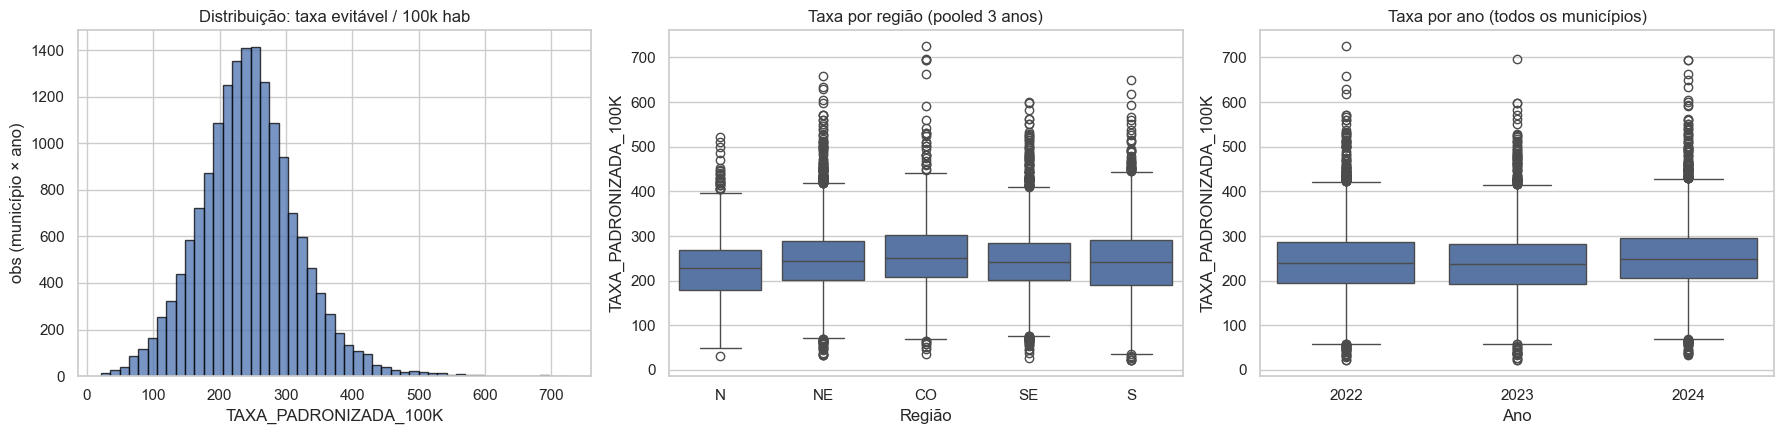


Média por ano:
        mean  median    std
ANO                        
2022  243.12  240.42  75.18
2023  238.92  237.20  72.60
2024  252.04  249.27  75.28


In [4]:
print(df_model[TARGET].describe().round(1))

regiao_real = fm.loc[df_model.index, "REGIAO"]
ano_real    = fm.loc[df_model.index, "ANO"]
ordem       = ["N", "NE", "CO", "SE", "S"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].hist(df_model[TARGET], bins=50, edgecolor="black", alpha=0.75)
axes[0].set_title("Distribuição: taxa evitável / 100k hab")
axes[0].set_xlabel(TARGET); axes[0].set_ylabel("obs (município × ano)")

sns.boxplot(x=regiao_real, y=df_model[TARGET], order=ordem, ax=axes[1])
axes[1].set_title("Taxa por região (pooled 3 anos)")
axes[1].set_xlabel("Região"); axes[1].set_ylabel(TARGET)

sns.boxplot(x=ano_real, y=df_model[TARGET], ax=axes[2])
axes[2].set_title("Taxa por ano (todos os municípios)")
axes[2].set_xlabel("Ano"); axes[2].set_ylabel(TARGET)

plt.tight_layout(); plt.show()

print("\nMédia por ano:")
print(df_model[TARGET].groupby(ano_real).agg(["mean", "median", "std"]).round(2))

## 3. Matriz de correlação (Pearson)

Mede a associação linear entre as features numéricas e o target. Sinaliza candidatos a colinearidade entre regressores.

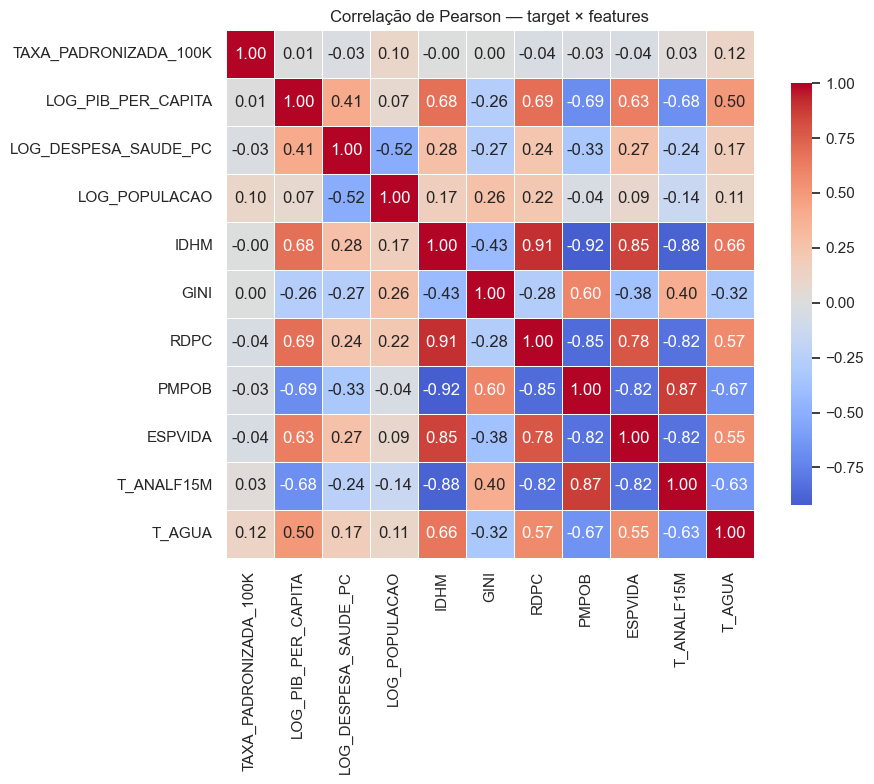


Correlações com o target (|r| > 0.15):
T_AGUA                  0.116
LOG_POPULACAO           0.099
RDPC                    0.042
ESPVIDA                 0.042
PMPOB                   0.028
T_ANALF15M              0.026
LOG_DESPESA_SAUDE_PC    0.026
LOG_PIB_PER_CAPITA      0.009
IDHM                    0.001
GINI                    0.000
Name: TAXA_PADRONIZADA_100K, dtype: float64


In [5]:
corr = df_model[[TARGET] + FEATURES_NUM].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlação de Pearson — target × features")
plt.tight_layout(); plt.show()

print("\nCorrelações com o target (|r| > 0.15):")
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).round(3))

## 4. Split treino/teste — `GroupShuffleSplit` por município

Com painel pooled, **um split aleatório de linhas** colocaria o mesmo município em treino e teste (anos diferentes). O modelo memorizaria características fixas do município (IDH, Gini, etc.) e o R² de teste ficaria inflado.

`GroupShuffleSplit` agrupa as 3 linhas de cada município e força que cada município esteja **inteiramente** em treino ou em teste — comportamento adequado para avaliar generalização.

In [6]:
X = df_model[FEATURES].copy()
y = df_model[TARGET].copy()
grupos_mun = df_model["CODMUN6"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
idx_train, idx_test = next(gss.split(X, y, groups=grupos_mun))

X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]
grupos_train    = grupos_mun[idx_train]

mun_train = set(df_model.iloc[idx_train]["CODMUN6"].unique())
mun_test  = set(df_model.iloc[idx_test]["CODMUN6"].unique())
print(f"Treino: {X_train.shape[0]:,} obs ({len(mun_train):,} municípios únicos)")
print(f"Teste : {X_test.shape[0]:,} obs ({len(mun_test):,} municípios únicos)")
print(f"Sobreposição de municípios entre treino e teste: {len(mun_train & mun_test)}  ← deve ser 0")
print(f"Média do target — treino={y_train.mean():.1f}, teste={y_test.mean():.1f}")

Treino: 13,269 obs (4,448 municípios únicos)
Teste : 3,322 obs (1,113 municípios únicos)
Sobreposição de municípios entre treino e teste: 0  ← deve ser 0
Média do target — treino=245.1, teste=242.9


## 5. Modelo Linear — OLS via `statsmodels` com cluster-robust SE

OLS oferece interpretação direta: cada coeficiente é o efeito esperado em pontos de taxa por 100k mantendo as demais variáveis constantes. P-values atestam significância estatística.

**Standard errors cluster-robust por município (`cov_type="cluster"`, `groups=CODMUN6`)** — corrige a correlação entre as 3 observações de cada município (mesma cidade gera resíduos correlacionados ano a ano). Sem isso, os SEs seriam subestimados e os p-values pareceriam mais significativos do que realmente são.

As dummies de **ANO** capturam choques de período (efeitos comuns a todos os municípios em cada ano: pós-COVID em 2022, normalização em 2023-2024, etc.).

In [7]:
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# Cluster-robust por município: corrige a dependência entre as 3 obs do mesmo município.
ols = sm.OLS(y_train, X_train_sm).fit(
    cov_type="cluster",
    cov_kwds={"groups": grupos_train},
)
print(ols.summary())

                              OLS Regression Results                             
Dep. Variable:     TAXA_PADRONIZADA_100K   R-squared:                       0.090
Model:                               OLS   Adj. R-squared:                  0.089
Method:                    Least Squares   F-statistic:                     56.56
Date:                   Sat, 30 May 2026   Prob (F-statistic):          2.92e-165
Time:                           21:30:31   Log-Likelihood:                -75416.
No. Observations:                  13269   AIC:                         1.509e+05
Df Residuals:                      13252   BIC:                         1.510e+05
Df Model:                             16                                         
Covariance Type:                 cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [8]:
coefs_ols = pd.DataFrame({
    "feature":   ols.params.index,
    "coef":      ols.params.values,
    "std_err":   ols.bse.values,
    "t":         ols.tvalues.values,
    "p_value":   ols.pvalues.values,
    "ci_low":    ols.conf_int()[0].values,
    "ci_high":   ols.conf_int()[1].values,
}).round(4)
coefs_ols["sig"] = coefs_ols["p_value"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)
coefs_ols

,feature,coef,std_err,t,p_value,ci_low,ci_high,sig
0,const,261.0821,56.0020,4.6620,0.0000,151.3202,370.8440,***
1,LOG_PIB_PER_CAPITA,1.8486,1.9412,0.9523,0.3410,-1.9562,5.6533,
2,LOG_DESPESA_SAUDE_PC,8.7858,3.0207,2.9085,0.0036,2.8653,14.7063,**
3,LOG_POPULACAO,12.9716,0.9207,14.0890,0.0000,11.1671,14.7762,***
4,IDHM,61.5433,42.2724,1.4559,0.1454,-21.3092,144.3957,
5,GINI,150.9909,19.4953,7.7450,0.0000,112.7808,189.2010,***
6,RDPC,-0.1378,0.0089,-15.4134,0.0000,-0.1554,-0.1203,***
7,PMPOB,-2.0724,0.1785,-11.6075,0.0000,-2.4224,-1.7225,***
8,ESPVIDA,-4.2323,0.6757,-6.2635,0.0000,-5.5567,-2.9080,***
9,T_ANALF15M,1.6712,0.2391,6.9893,0.0000,1.2026,2.1399,***


## 6. Random Forest

Captura interações e efeitos não-lineares (ex.: efeito do IDH-M pode ser mais forte em municípios pequenos do que em grandes) sem precisar especificar a forma funcional. Hiperparâmetros conservadores — mais foco na robustez do que em fine-tuning.

In [9]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
print("Random Forest treinado.")
print(f"Profundidade média das árvores: {np.mean([t.tree_.max_depth for t in rf.estimators_]):.1f}")

Random Forest treinado.
Profundidade média das árvores: 12.0


## 7. XGBoost

Gradient boosting com regularização. Costuma ser o estado da arte em tabular regression — incluído como teto de performance para julgar quanto da variância na taxa de mortalidade evitável é explicável pelas variáveis socioeconômicas.

In [10]:
xgb = XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="rmse",
    early_stopping_rounds=30,
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print(f"XGBoost treinado | best_iteration = {xgb.best_iteration}")

XGBoost treinado | best_iteration = 88


## 8. Comparação de modelos

Avalia os três modelos no hold-out de teste com R² (explained variance), RMSE (em pontos de taxa) e MAE.

In [11]:
def avaliar(nome, y_true, y_pred):
    return {
        "modelo": nome,
        "R2":     r2_score(y_true, y_pred),
        "RMSE":   np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":    mean_absolute_error(y_true, y_pred),
    }

pred_ols = ols.predict(X_test_sm)
pred_rf  = rf.predict(X_test)
pred_xgb = xgb.predict(X_test)

metricas = pd.DataFrame([
    avaliar("OLS (linear)",      y_test, pred_ols),
    avaliar("Random Forest",     y_test, pred_rf),
    avaliar("XGBoost",           y_test, pred_xgb),
]).round(3)
metricas

,modelo,R2,RMSE,MAE
0,OLS (linear),0.092,71.004,53.920
1,Random Forest,0.091,71.018,54.100
2,XGBoost,0.103,70.554,53.703


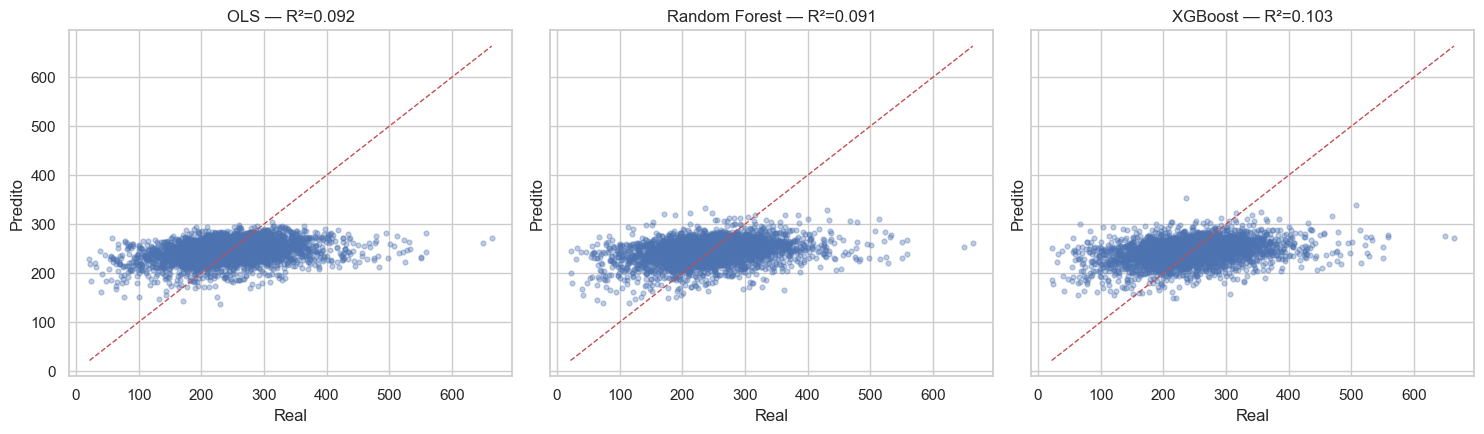

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (nome, pred) in zip(axes, [("OLS", pred_ols), ("Random Forest", pred_rf), ("XGBoost", pred_xgb)]):
    ax.scatter(y_test, pred, alpha=0.35, s=12)
    lo, hi = y_test.min(), y_test.max()
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    ax.set_title(f"{nome} — R²={r2_score(y_test, pred):.3f}")
    ax.set_xlabel("Real"); ax.set_ylabel("Predito")
plt.tight_layout(); plt.show()

## 9. Importância das features

RF usa redução média de impureza; XGBoost, ganho médio nas splits. As escalas não são comparáveis entre os dois, mas o *ranking* costuma ser consistente — quando concordam, a leitura é mais confiável.

In [13]:
importancia = pd.DataFrame({
    "feature":   FEATURES,
    "imp_rf":    rf.feature_importances_,
    "imp_xgb":   xgb.feature_importances_,
})
importancia["rank_rf"]  = importancia["imp_rf"].rank(ascending=False).astype(int)
importancia["rank_xgb"] = importancia["imp_xgb"].rank(ascending=False).astype(int)
importancia = importancia.sort_values("imp_rf", ascending=False).reset_index(drop=True)
importancia.round(4)

,feature,imp_rf,imp_xgb,rank_rf,rank_xgb
0,LOG_POPULACAO,0.1654,0.0574,1,9
1,T_AGUA,0.1302,0.0746,2,5
2,T_ANALF15M,0.1021,0.0672,3,7
3,RDPC,0.1017,0.0719,4,6
4,PMPOB,0.0893,0.0655,5,8
5,LOG_DESPESA_SAUDE_PC,0.0847,0.0363,6,14
6,ESPVIDA,0.0825,0.0572,7,10
7,LOG_PIB_PER_CAPITA,0.0819,0.0332,8,15
8,IDHM,0.0583,0.0478,9,12
9,GINI,0.0449,0.0439,10,13


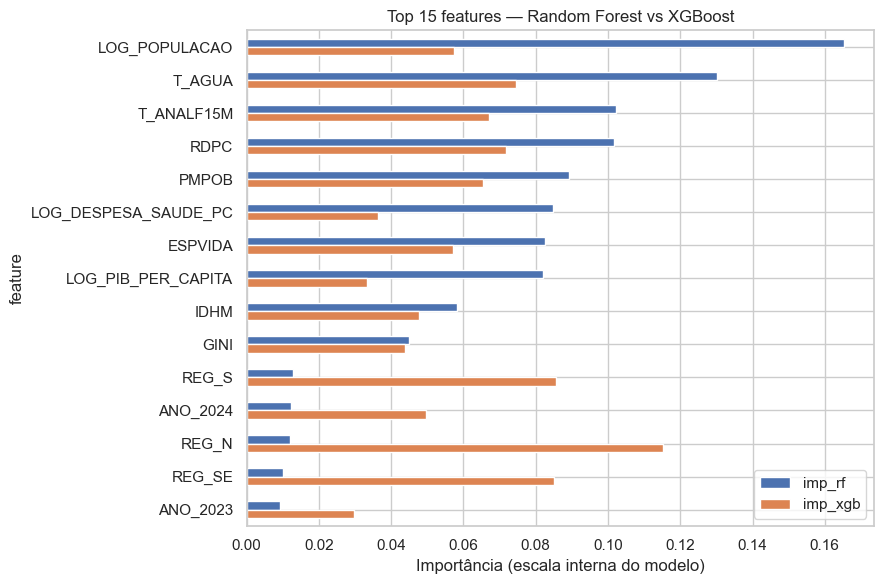

In [14]:
top = importancia.head(15).set_index("feature")[["imp_rf", "imp_xgb"]]
fig, ax = plt.subplots(figsize=(9, 6))
top.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Top 15 features — Random Forest vs XGBoost")
ax.set_xlabel("Importância (escala interna do modelo)")
plt.tight_layout(); plt.show()

## 10. Análise contrafactual

**Pergunta:** se elevarmos o IDH-M dos municípios do **quintil mais pobre** (1º quintil de IDH-M) ao patamar mediano (3º quintil) — mantendo as demais variáveis fixas — quanto cairia a taxa de mortalidade evitável prevista?

É uma simulação *ceteris paribus*, não uma previsão causal. Mas dá ordem de grandeza para o efeito "se conseguíssemos elevar o desenvolvimento humano…" — exatamente a leitura que a tese do projeto sustenta.

In [15]:
X_full = df_model[FEATURES].copy()
y_full = df_model[TARGET].values
idhm_full = df_model["IDHM"].values

q20, q60 = np.quantile(idhm_full, [0.20, 0.60])
mascara_pobres = idhm_full <= q20

X_cf = X_full.copy()
X_cf.loc[mascara_pobres, "IDHM"] = q60

# usa o XGBoost (melhor RMSE em geral) para a simulação
pred_base = xgb.predict(X_full)
pred_cf   = xgb.predict(X_cf)

delta = pred_cf[mascara_pobres] - pred_base[mascara_pobres]
n_aff = mascara_pobres.sum()
print(f"Municípios afetados (quintil inferior de IDH-M): {n_aff:,}")
print(f"IDH-M antes (média)  : {idhm_full[mascara_pobres].mean():.3f}")
print(f"IDH-M depois (cf)    : {q60:.3f}")
print()
print(f"Taxa evitável média ANTES   : {pred_base[mascara_pobres].mean():.1f} / 100k")
print(f"Taxa evitável média DEPOIS  : {pred_cf[mascara_pobres].mean():.1f} / 100k")
print(f"Variação média absoluta     : {delta.mean():+.1f} / 100k")
print(f"Variação média relativa     : {delta.mean() / pred_base[mascara_pobres].mean() * 100:+.1f}%")

Municípios afetados (quintil inferior de IDH-M): 3,340
IDH-M antes (média)  : 0.557
IDH-M depois (cf)    : 0.689

Taxa evitável média ANTES   : 240.4 / 100k
Taxa evitável média DEPOIS  : 238.0 / 100k
Variação média absoluta     : -2.4 / 100k
Variação média relativa     : -1.0%


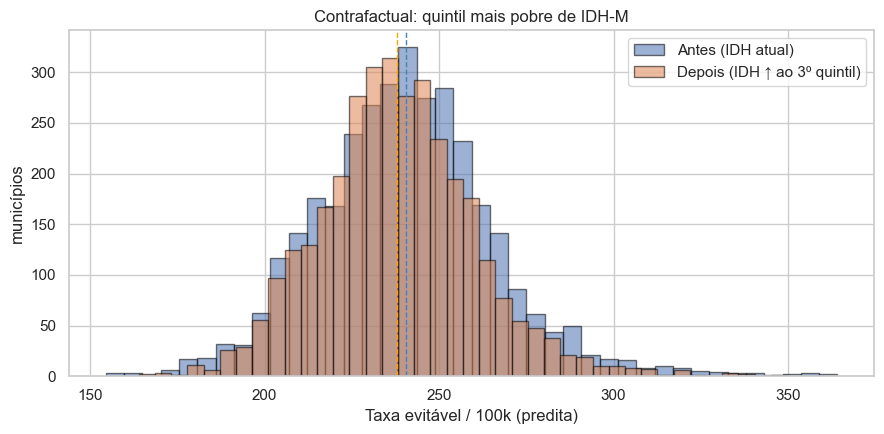

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(pred_base[mascara_pobres], bins=40, alpha=0.55, label="Antes (IDH atual)", edgecolor="black")
ax.hist(pred_cf[mascara_pobres],   bins=40, alpha=0.55, label="Depois (IDH ↑ ao 3º quintil)", edgecolor="black")
ax.axvline(pred_base[mascara_pobres].mean(), color="steelblue", linestyle="--", linewidth=1)
ax.axvline(pred_cf[mascara_pobres].mean(),   color="orange",    linestyle="--", linewidth=1)
ax.set_title("Contrafactual: quintil mais pobre de IDH-M")
ax.set_xlabel("Taxa evitável / 100k (predita)")
ax.set_ylabel("municípios")
ax.legend()
plt.tight_layout(); plt.show()

## 11. Persistência

Salva as predições por município, métricas dos modelos, coeficientes do OLS e ranking de importâncias. São os artefatos que entram no relatório final e no notebook de mineração.

In [17]:
predicoes = pd.DataFrame({
    "CODMUN6":         df_model["CODMUN6"].values,
    "MUNICIPIO_NOME":  df_model["MUNICIPIO_NOME"].values,
    "UF":              df_model["UF"].values,
    "TAXA_REAL":       y_full,
    "TAXA_PRED_OLS":   ols.predict(sm.add_constant(X_full)).values,
    "TAXA_PRED_RF":    rf.predict(X_full),
    "TAXA_PRED_XGB":   pred_base,
    "TAXA_PRED_CF":    pred_cf,
    "NO_QUINTIL_POBRE": mascara_pobres,
})
predicoes["RESIDUO_XGB"] = predicoes["TAXA_REAL"] - predicoes["TAXA_PRED_XGB"]

out_pred = PROCESSED_DIR / "predicoes_modelo.parquet"
out_met  = MODELS_DIR / "metricas_modelos.csv"
out_ols  = MODELS_DIR / "coeficientes_ols.csv"
out_imp  = MODELS_DIR / "importancia_features.csv"

predicoes.to_parquet(out_pred, index=False)
metricas.to_csv(out_met, index=False)
coefs_ols.to_csv(out_ols, index=False)
importancia.to_csv(out_imp, index=False)

for p in (out_pred, out_met, out_ols, out_imp):
    print(f"  {p.name:<32} → {p.stat().st_size / 1e3:>7.1f} KB")

  predicoes_modelo.parquet         →   992.5 KB
  metricas_modelos.csv             →     0.1 KB
  coeficientes_ols.csv             →     1.0 KB
  importancia_features.csv         →     0.8 KB


---

**Leitura dos resultados:**

- O OLS dá a leitura interpretável — coeficientes com p-value sinalizam quais drivers socioeconômicos têm efeito estatisticamente robusto sobre a taxa de mortalidade evitável.
- RF e XGBoost mostram o teto de variância explicável (R²) com as features atuais; se o teto é baixo, há determinantes relevantes fora do conjunto (estrutura da rede de saúde, qualidade do registro de óbitos, fatores culturais).
- A análise contrafactual quantifica o efeito esperado de elevar o IDH-M dos municípios mais pobres — sustenta a tese de que **desigualdade socioeconômica explica parte significativa da mortalidade evitável no Brasil**.

**Próximo passo:** `04_mineracao.ipynb` — clustering de municípios por padrão de mortalidade evitável + análise textual dos CIDs (top causas por cluster).